# 06 — N64 reconstruction: 64-bubble GW spectrum comparison

Compare the 3D sledgehamr run (64 bubbles, L=200, λ̄=0.84) with the
spectrum reconstructed from the 1D BM scan × collision weights.

Two comparison times:
- **T₁**: last available SH snapshot
- **T₂**: time when all pair weights drop to zero (last collision)

**Workflow**
1. Run **Section 1** to write the weights input file and generate a shell script.
2. Execute: `bash scripts/run_weights_N64.sh`
3. Run **Sections 2–5** to load data and produce the comparison plot.

In [1]:
import glob
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path

import ptbuilder as pt
from ptbuilder.physics import InstantonProfile, BubbleKinematics
from ptbuilder.analysis import write_weights_input, load_weights
from ptbuilder.scan import load_scan
from ptbuilder.ic import _cutoff_times

# 64 bubble positions from reference_codes/notebooks/Scan.ipynb
bubbles = np.array([[  0.        ,   0.        ,   0.        ],
       [104.21080818, 134.00331875, 115.32260336],
       [ 82.91633086,  40.22040859, 161.10457444],
       [162.20889478, 164.79584079,   2.8384039 ],
       [154.47733984, 187.65793396,  20.16866321],
       [199.13096101,  27.01104231,  45.30013382],
       [168.5003722 ,  38.64441063,  52.81041635],
       [133.97360158,  91.59693268, 138.34643773],
       [ 50.28297449,  51.95537184,  23.62294384],
       [177.13769118, 134.66889799,   8.71668886],
       [ 30.68289591,   9.45788771,  50.50424856],
       [ 64.12769861, 195.12306707,  81.57164046],
       [ 56.68936652, 130.84497227, 108.2354709 ],
       [ 82.99174886, 121.03920058, 172.37415331],
       [127.09687502, 120.51398912, 134.53558472],
       [ 33.36926752,  13.63720659,   0.60996262],
       [ 18.39375397, 191.40492629, 122.47329764],
       [ 19.63641252,  63.09685344, 174.17147189],
       [ 90.74169878, 154.13735512, 104.39306946],
       [ 86.557716  ,  72.91515918, 182.95789915],
       [119.33310673,  37.76924713, 149.28485556],
       [ 17.13480987, 132.62322674, 189.63031283],
       [109.46636148, 118.08537517,  76.31000499],
       [170.09845239,   3.4854559 ,  23.50245978],
       [ 18.70476325, 147.66938079,  58.80734523],
       [111.64277024, 157.053698  , 132.24005744],
       [ 42.14101276,  50.93855746, 176.75407925],
       [ 14.51198083,  16.93867057,  60.2360491 ],
       [ 52.77856703,  29.30614115,  36.71599   ],
       [ 38.07656718,  13.10864189,  72.07363165],
       [138.51107657, 177.90126384, 114.77664924],
       [ 25.84809123, 112.82413992,  33.27661835],
       [  6.6733563 , 160.69190438, 139.70034561],
       [197.70475434,  13.8230847 ,  60.37034021],
       [ 12.25179549, 100.55314862,  78.92943814],
       [140.93499401, 164.76389065, 124.56483354],
       [100.40316917,  68.76075668,  17.56098047],
       [144.15542294,  50.57241845,  83.47993277],
       [ 43.42498771,  75.67311377, 122.44988237],
       [ 73.56937364,  38.65136447,   0.68298585],
       [160.40914341,   1.50148649,   2.225444  ],
       [127.8706212 ,  29.43082072,  23.094503  ],
       [ 10.24110325, 111.83791255, 156.45308871],
       [161.49404006, 163.38664412, 161.98093237],
       [ 27.04229405,  45.36589381, 117.35604037],
       [126.85079112, 162.26356355,  70.60492779],
       [128.66689612,  68.71766065, 150.35375572],
       [166.89624473, 124.99140447,  49.97804878],
       [ 22.58882999, 172.17683864,  41.74842148],
       [173.1491633 , 103.35193697,  79.45686904],
       [ 63.47467018, 157.89290094,  54.88476635],
       [ 83.264726  , 141.90140818, 151.48688241],
       [ 71.99367711,  16.40398225, 197.67281455],
       [ 55.41434491, 148.76063021,   3.30900276],
       [136.79240841,  60.8792625 , 193.43780416],
       [ 21.14423948,  15.16246438, 137.40606156],
       [ 37.08759453,  55.1292117 ,  75.06349727],
       [  6.48071698, 123.73465632,   4.00908165],
       [ 49.63963798,  63.59991319, 136.27840358],
       [  6.47400652, 161.05000329, 163.66077338],
       [142.56695796, 110.77450728, 194.29867779],
       [ 85.21456401,  72.43223496, 118.71280211],
       [103.95645911,   4.65524665, 154.29805374],
       [151.90410329, 147.74780743,  72.22549058]])

In [2]:
REPO_ROOT   = Path(pt.__file__).parent.parent
SH_RUNS_DIR = REPO_ROOT / 'sledgehamr_runs'
DATA_DIR    = REPO_ROOT / 'data'

lb         = 0.84
L          = 200.
zero_pad   = 1.
N_WEIGHTS  = 1024
T_SCAN_MAX = 70.
N_SCAN     = 32

WEIGHTS_IN  = DATA_DIR / 'weights_in_N64.h5'
WEIGHTS_OUT = DATA_DIR / 'weights_out_N64.h5'
SH_PATH     = SH_RUNS_DIR / 'bubbles_N64'

scan_times    = np.linspace(1., T_SCAN_MAX, N_SCAN)
weights_times = np.linspace(1., T_SCAN_MAX, N_WEIGHTS)

_KEFFSQ_PATH     = REPO_ROOT / 'reference_codes/FirstOrder_GW/collision_weights/keff.npy'
_keffsq_register = np.load(_KEFFSQ_PATH, allow_pickle=True).item()

def _dim_from_nbins(nbins):
    dim_est = 2 * (nbins - 1) / np.sqrt(3)
    return 2 ** int(round(np.log2(dim_est)))

def _apply_keffsq(k_int):
    return _keffsq_register[_dim_from_nbins(len(k_int))]

## 1. Set up weights calculation

Writes the HDF5 input file for the `cpp/weights` binary and generates a shell script.

In [3]:
def load_kinematics_local(lb):
    """Load BubbleKinematics from stored instanton.h5 (no C++ needed)."""
    path = DATA_DIR / f'phi4_lambda_bar{lb}' / 'instanton.h5'
    with h5py.File(path, 'r') as f:
        profile = InstantonProfile(
            R=f['R'][:], Phi=f['Phi'][:],
            rin_0 =float(f.attrs['rin_0']),
            rmid_0=float(f.attrs['rmid_0']),
            rout_0=float(f.attrs['rout_0']),
            interp=None,
        )
    return BubbleKinematics(profile)


kin = load_kinematics_local(lb)

write_weights_input(
    path=WEIGHTS_IN,
    positions=bubbles,
    t=weights_times,
    kinematics=kin,
    L=L,
)
print(f'Written: {WEIGHTS_IN.name}')

weights_bin = REPO_ROOT / 'cpp/weights/weights'
scripts_dir = REPO_ROOT / 'scripts'
scripts_dir.mkdir(exist_ok=True)
script = '\n'.join([
    '#!/bin/bash',
    '# Run from repo root:  bash scripts/run_weights_N64.sh',
    '',
    f'{weights_bin} {WEIGHTS_IN} {WEIGHTS_OUT}',
])
(scripts_dir / 'run_weights_N64.sh').write_text(script)
print(f'\nRun: bash scripts/run_weights_N64.sh')

Written: weights_in_N64.h5

Run: bash scripts/run_weights_N64.sh


## 2. Load scan results

In [4]:
cache = DATA_DIR / f'phi4_lambda_bar{lb}' / 'scan_cache.h5'
scan_results = load_scan(cache)
actual_t = next(iter(scan_results.values())).times
print(f'lb={lb}: {len(scan_results)} gamma values  '
      f't=[{actual_t[0]:.1f}, {actual_t[-1]:.1f}]  n_t={len(actual_t)}')

lb=0.84: 32 gamma values  t=[1.0, 70.0]  n_t=32


## 3. Load collision weights

Run `bash scripts/run_weights_N64.sh` before executing this cell.

In [5]:
if not WEIGHTS_OUT.exists():
    print('Weights not found — run scripts/run_weights_N64.sh')
else:
    weights, pair_i, pair_j, gammas = load_weights(WEIGHTS_OUT, N_WEIGHTS)
    n_pairs = len(pair_i)
    print(f'{n_pairs} colliding pairs')

    pair_d  = np.zeros(n_pairs)
    pair_tm = np.zeros(n_pairs)
    for p in range(n_pairs):
        i, j = int(pair_i[p]), int(pair_j[p])
        dp = bubbles[i] - bubbles[j]
        dp -= L * np.round(dp / L)
        d = float(np.linalg.norm(dp))
        pair_d[p]  = d
        pair_tm[p] = float(_cutoff_times(d, 0, 1.)[2])   # BM comparison time ≈ 1.095*d

    print(f'd     range: [{pair_d.min():.2f}, {pair_d.max():.2f}]')
    print(f'gamma range: [{gammas.min():.4f}, {gammas.max():.4f}]')
    print(f't_m   range: [{pair_tm.min():.2f}, {pair_tm.max():.2f}]')

328 colliding pairs
d     range: [16.56, 133.02]
gamma range: [1.0799, 9.5776]
t_m   range: [18.13, 145.66]


## 4. Load sledgehamr 3D spectrum

In [6]:
def _list_gw_files(sh_path):
    pattern = os.path.join(sh_path, 'gw_spectra', '*', 'spectra.hdf5')
    entries = []
    for fp in glob.glob(pattern):
        dname = os.path.basename(os.path.dirname(fp))
        if dname.isdigit():
            entries.append((int(dname), fp))
    entries.sort(key=lambda x: x[0])
    return entries


def _read_gw_file(fp):
    with h5py.File(fp, 'r') as f:
        k_int = np.asarray(f['k' if 'k' in f else 'k_sq'][:])
        spec  = np.asarray(f['Spectrum' if 'Spectrum' in f else 'spectrum'][:])
        hdr   = np.asarray(f['Header'][:]).reshape(-1)
        t     = float(hdr[0])
    return _apply_keffsq(k_int), spec, t


def load_sh_all_snaps(sh_path):
    files = _list_gw_files(sh_path)
    if not files:
        raise FileNotFoundError(f'No gw_spectra/*/spectra.hdf5 in {sh_path}')
    snaps = [_read_gw_file(fp) for _, fp in files]
    snaps.sort(key=lambda x: x[2])
    return snaps


def normalize_sh(k_sq, spectrum, L, zero_pad):
    if k_sq[0] == 0:
        k_sq     = k_sq[1:]
        spectrum = spectrum[1:]
    Leff = L * zero_pad
    r    = np.sqrt(k_sq)
    k    = r * (2 * np.pi / Leff)
    norm = 4.0 * (2 * np.pi * r) * Leff**3
    return k, spectrum * norm


sh_snaps = load_sh_all_snaps(SH_PATH)
t0 = sh_snaps[0][2]
t1 = sh_snaps[-1][2]
print(f'{len(sh_snaps)} snapshots, t=[{t0:.2f}, {t1:.2f}]')

46 snapshots, t=[0.00, 90.01]


## 5. Reconstruct and compare

In [7]:
from scipy.interpolate import RegularGridInterpolator


def build_log_scan_interpolator(scan_results, k_out):
    gammas = np.array(sorted(scan_results.keys()))
    times  = next(iter(scan_results.values())).times
    Ng, Nt, Nk = len(gammas), len(times), len(k_out)

    spec_grid = np.zeros((Ng, Nt, Nk))
    for ig, gamma in enumerate(gammas):
        res = scan_results[gamma]
        for it in range(Nt):
            spec_grid[ig, it] = np.interp(k_out, res.w, res.spectrum[it],
                                           left=0., right=0.)

    floor     = spec_grid.max() * 1e-12
    log_grid  = np.log(np.maximum(spec_grid, floor))
    log_floor = np.log(floor)

    _raw = RegularGridInterpolator(
        (gammas, times), log_grid,
        bounds_error=False, fill_value=log_floor,
    )

    def interp_fn(pts):
        return np.exp(_raw(pts))

    return interp_fn, gammas, times, k_out


def bm_reconstruct(gamma, weights_t, weights_times, t_max, interp_fn, times, gammas):
    g = float(np.clip(gamma, gammas.min(), gammas.max()))

    locs   = np.where(times <= t_max)[0]
    t_comp = times[locs]
    if len(t_comp) == 0 or t_comp[-1] < t_max:
        t_comp = np.append(t_comp, min(t_max, times[-1]))

    w = np.interp(t_comp, weights_times, weights_t)

    pts   = np.column_stack([np.full(len(t_comp), g), t_comp])
    specs = interp_fn(pts)

    delta = np.diff(specs, axis=0)
    return (w[:len(t_comp) - 1, None] * delta).sum(axis=0)


def interp_sh_at_t(snaps, t_target):
    ts = np.array([s[2] for s in snaps])
    if t_target <= ts[0]:
        return snaps[0][0], snaps[0][1], ts[0]
    if t_target >= ts[-1]:
        return snaps[-1][0], snaps[-1][1], ts[-1]
    i = int(np.searchsorted(ts, t_target)) - 1
    k_sq, s_a, t_a = snaps[i]
    _,    s_b, t_b = snaps[i + 1]
    alpha = (t_target - t_a) / (t_b - t_a)
    floor = max(s_a.max(), s_b.max()) * 1e-12
    log_a = np.log(np.maximum(s_a, floor))
    log_b = np.log(np.maximum(s_b, floor))
    return k_sq, np.exp(log_a + alpha * (log_b - log_a)), t_target

T1 = 90.01  (last snapshot)
T2 = 70.00  (last collision complete)


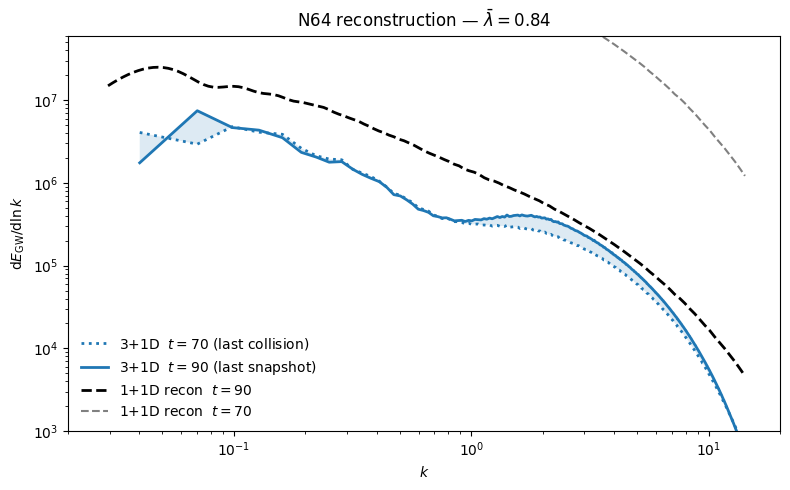

In [23]:
# Comparison times.
# Weights are 0 before AND after each collision (they peak during the event).
# T2 = last time any pair is still actively colliding (sum_w > threshold).
T1 = sh_snaps[-1][2]  # last snapshot — upper limit

sum_w  = weights.sum(axis=0)            # (n_weights,) — summed over all pairs
active = np.where(sum_w > 0.01)[0]
T2     = float(weights_times[active[-1]]) if len(active) else weights_times[-1]

print(f'T1 = {T1:.2f}  (last snapshot)')
print(f'T2 = {T2:.2f}  (last collision complete)')

# Build scan interpolator
first_res = next(iter(scan_results.values()))
k_out = first_res.w
interp_fn, gammas_grid, scan_t, _ = build_log_scan_interpolator(scan_results, k_out)

# BM reconstruction at T1 and T2
recon = {}
for T in [T1, T2]:
    c = np.zeros(len(k_out))
    for p in range(n_pairs):
        c += bm_reconstruct(float(gammas[p]), weights[p], weights_times, T,
                            interp_fn, scan_t, gammas_grid)
    recon[T] = c

# 3D SH spectra at T1 and T2
sh_at = {}
for T in [T1, T2]:
    k_sq, spec, t_act = interp_sh_at_t(sh_snaps, T)
    k_sh, y_sh = normalize_sh(k_sq, spec, L, zero_pad)
    sh_at[T] = (k_sh, y_sh, t_act)

fig, ax = plt.subplots(figsize=(8, 5))

k1, y1, ta1 = sh_at[T1]
k2, y2, ta2 = sh_at[T2]

# 3D SH: shaded band between T2 (lower) and T1 (upper)
y2_r = np.interp(k1, k2, y2, left=0., right=0.)
ax.fill_between(k1, y2_r, y1, color='C0', alpha=0.15, linewidth=0)
ax.plot(k2, y2, color='C0', lw=2, linestyle=':', label=rf'3+1D  $t={ta2:.0f}$ (last collision)')
ax.plot(k1, y1, color='C0', lw=2,              label=rf'3+1D  $t={ta1:.0f}$ (last snapshot)')

fudge=0.8
# BM reconstruction — T1 and T2 should nearly overlap
ax.plot(k_out, recon[T1], color='black', lw=2,   linestyle='--', label=rf'1+1D recon  $t={T1:.0f}$')
ax.plot(k_out, recon[T2]*(1-fudge**328), color='gray',  lw=1.5, linestyle='--', label=rf'1+1D recon  $t={T2:.0f}$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e3,6e7)
ax.set_xlim(0.02,20)
ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$\mathrm{d}E_{\mathrm{GW}}/\mathrm{d}\ln k$')
ax.legend(frameon=False)
ax.set_title(rf'N64 reconstruction — $\bar{{\lambda}}={lb}$')
plt.tight_layout()
plt.savefig(REPO_ROOT / 'n64_reconstruction.pdf', bbox_inches='tight')
plt.show()

In [28]:
np.exp(328)

2.8092478959838913e+142